In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor



In [4]:
laptops = pd.read_csv("laptop_data_cleaned.csv")

In [27]:

X = laptops[["Price", "Competitor_Price", "Customer_Rating", "Performance_Index"]]
y = laptops["Demand_Index"]



In [28]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X, y)





,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [30]:

price_range = np.linspace(laptops["Price"].min(), laptops["Price"].max(), 200)


In [31]:

X_test = pd.DataFrame({
    "Price": price_range,
    "Competitor_Price": laptops["Competitor_Price"].mean(),
    "Customer_Rating": laptops["Customer_Rating"].mean(),
    "Performance_Index": laptops["Performance_Index"].mean()
})



In [32]:
demand_pred = xgb.predict(X_test)
demand_pred = np.clip(demand_pred, 0, None)  # no negative demand




In [33]:
revenues = price_range * demand_pred



In [35]:
optimal_price = price_range[np.argmax(revenues)]
max_revenue = float(np.max(revenues))

print(f"Optimal Price (XGBoost): {optimal_price:.2f}")
print(f"Expected Max Revenue: {max_revenue:.2f}")



Optimal Price (XGBoost): 416.74
Expected Max Revenue: 31719.49


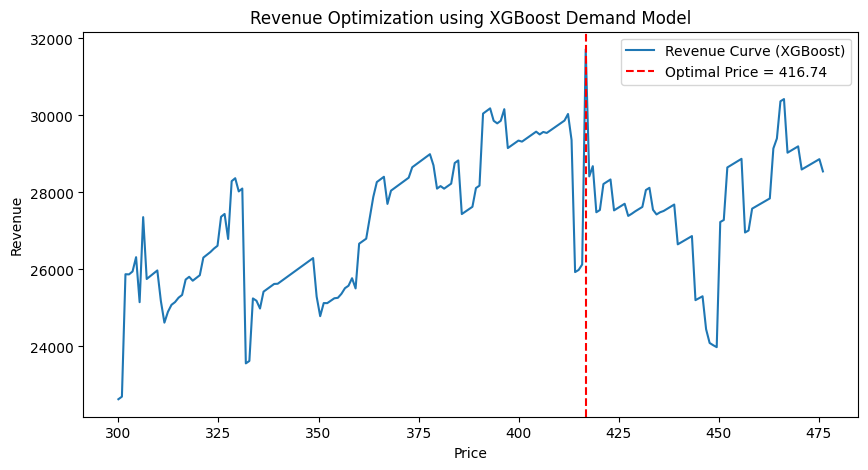

In [36]:

plt.figure(figsize=(10,5))


plt.plot(price_range, revenues, label="Revenue Curve (XGBoost)")
plt.axvline(optimal_price, color="red", linestyle="--", label=f"Optimal Price = {optimal_price:.2f}")

plt.xlabel("Price")
plt.ylabel("Revenue")
plt.title("Revenue Optimization using XGBoost Demand Model")
plt.legend()
plt.show()